# Multi-Omics WGCNA Tutorial

## WGCNA on Expression + Module-QTL (mQTL) on Genotypes

A best-practice multi-omics workflow:

1. Build the co-expression network on **expression only** (WGCNA's domain).
2. Reduce each module to its **eigengene** (PC1 of member genes).
3. Treat each module eigengene as a **quantitative trait**, then map SNPs against it (**mQTL** — module-QTL).

Mixing 0/1/2 genotype dosages with continuous expression in a single correlation network conflates fundamentally different signal types. Building the network on expression alone keeps modules biologically interpretable; genotypes are then tested *afterward* as candidate causal drivers.

### Dataset
- 300 samples (200 ASD cases, 100 controls)
- 100 genes from bulk RNA-seq → used to build co-expression modules
- 50 SNPs from WGS data (0/1/2 dosage) → tested against module eigengenes via mQTL
- Clinical covariates: ASD status, Age, Sex, IQ, ADOS Score

### Steps
1. Load expression, genotypes, covariates
2. Preprocess expression (log2 + standardize); inspect genotypes
3. Compute gene–gene similarity (Pearson)
4. Choose soft-thresholding power (scale-free topology)
5. Build adjacency + TOM matrices
6. Hierarchical clustering → identify gene modules
7. Compute module eigengenes (PC1 per module)
8. Relate modules to clinical traits
9. **mQTL**: regress each SNP against each module eigengene

---
## Step 1: Setup and Data Loading

In [49]:
# -----------------------------------------------------------------------------
# Imports
#
# We rely on three layers of libraries:
#   * numpy / pandas             — numerical core and data frames
#   * matplotlib / seaborn       — visualisation
#   * scipy / scikit-learn       — statistics, hierarchical clustering, PCA
#
# All WGCNA-style maths is reimplemented directly with these tools so the
# conceptual steps stay visible in code (rather than hidden behind an R wrapper).
# -----------------------------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats                                   # Pearson r, linregress
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform
from sklearn.preprocessing import StandardScaler          # z-score genes
from sklearn.decomposition import PCA                     # module eigengene = PC1
from sklearn.linear_model import LinearRegression         # scale-free fit

import warnings
warnings.filterwarnings('ignore')                         # silence pandas/numpy chatter

# Reproducibility + cosmetics
plt.style.use('seaborn-v0_8-darkgrid')
np.random.seed(42)
%matplotlib inline

print("Libraries loaded successfully")


Libraries loaded successfully


In [50]:
# -----------------------------------------------------------------------------
# Load the three input tables for a multi-omics WGCNA + mQTL workflow
#
#   ASD_expression.csv   samples x genes      (RNA-seq counts)
#   ASD_genotypes.csv    samples x SNPs       (allele dosages 0/1/2)
#   ASD_covariates.csv   samples x phenotypes (ASD status, Age, Sex, IQ, ADOS)
#
# Critical: the three matrices may have different sample sets (missing
# genotypes, missing clinical data, ...). We INTERSECT their indices first so
# every downstream step works on exactly the same individuals.
# -----------------------------------------------------------------------------
DATA_DIR = "../data/ASD_dataset/"

expression = pd.read_csv(f"{DATA_DIR}ASD_expression.csv").set_index('sample')
genotypes  = pd.read_csv(f"{DATA_DIR}ASD_genotypes.csv").set_index('sample')
covariates = pd.read_csv(f"{DATA_DIR}ASD_covariates.csv").set_index('sample')

# Align all tables on the common set of samples (preserves order from `expression`)
samples = expression.index.intersection(genotypes.index).intersection(covariates.index)
expression = expression.loc[samples]
genotypes  = genotypes.loc[samples]
covariates = covariates.loc[samples]

print("Data shapes (aligned):")
print(f"  Expression: {expression.shape[0]} samples x {expression.shape[1]} genes")
print(f"  Genotypes:  {genotypes.shape[0]} samples x {genotypes.shape[1]} SNPs")
print(f"  Covariates: {covariates.shape[0]} samples x {covariates.shape[1]} variables")


Data shapes (aligned):
  Expression: 300 samples x 100 genes
  Genotypes:  300 samples x 50 SNPs
  Covariates: 300 samples x 8 variables


---
## Step 2: Preprocess Expression (and inspect genotypes)

WGCNA operates on **expression only** in this workflow:
1. Log-transform: `log2(x + 1)` — RNA-seq counts span orders of magnitude
2. Z-score standardize per gene — fair comparison across genes

Genotypes are **not merged** into the network. They are kept aside in their
original 0/1/2 dosage encoding for the downstream mQTL step (Step 9).

In [51]:
# -----------------------------------------------------------------------------
# Pre-process the EXPRESSION matrix for WGCNA
#
# Two transforms, in order:
#   1. log2(x + 1)
#        RNA-seq counts span several orders of magnitude (0 to thousands).
#        Without a log, a handful of highly expressed genes would dominate
#        the variance and any subsequent z-score would be skewed by them.
#        The "+1" pseudo-count keeps log defined when the count is 0.
#
#   2. Z-score per gene (mean=0, std=1)
#        Co-expression analysis is correlation-based; correlations are
#        invariant to scaling, BUT z-scoring stabilises numerics and lets
#        us treat all genes on equal footing in downstream PCA / clustering.
#
# Genotypes are NOT processed here. They are kept in their native 0/1/2
# encoding for the mQTL step (Step 9), where the slope coefficient should
# read as "effect per copy of the alt allele".
# -----------------------------------------------------------------------------
print("Preprocessing Expression Data")
print("="*50)

# Step 1: log-transform raw counts
expr_log = np.log2(expression + 1)
print("Applied log2(x+1) transformation")

# Step 2: per-gene standardisation
scaler_expr = StandardScaler()
expr_scaled = pd.DataFrame(
    scaler_expr.fit_transform(expr_log),
    index=expression.index,
    columns=expression.columns,
)
print(f"Z-score standardized: mean={expr_scaled.mean().mean():.4f}, "
      f"std={expr_scaled.std().mean():.4f}")
print(f"Expression shape: {expr_scaled.shape}")

# `expr_data` is the canonical name we'll feed to every WGCNA step below.
# Genotypes are kept entirely separate — that is the whole point of this
# best-practice multi-omics layout.
expr_data = expr_scaled
print("\nWGCNA input matrix: samples x genes  (no genotypes merged in)")


Preprocessing Expression Data
Applied log2(x+1) transformation
Z-score standardized: mean=-0.0000, std=1.0017
Expression shape: (300, 100)

WGCNA input matrix: samples x genes  (no genotypes merged in)


In [52]:
# -----------------------------------------------------------------------------
# Inspect the GENOTYPE matrix (it is held aside for the mQTL step)
#
# The three pieces of information that matter at this stage:
#   * Dosage distribution           — sanity check the 0/1/2 encoding
#   * Minor-allele frequency (MAF)  — very low MAF = unstable mQTL effects
#   * Monomorphic SNPs              — zero variance = no possible association
#                                     (their regression slope is undefined)
# -----------------------------------------------------------------------------
print("Genotype Data — NOT merged into the WGCNA network")
print("="*50)

print(f"Genotype shape: {genotypes.shape}  (samples x SNPs)")

# Tally how many cells in the matrix have each dosage value
unique, counts = np.unique(genotypes.values, return_counts=True)
print("\nDosage distribution (0=hom ref, 1=het, 2=hom alt):")
for v, c in zip(unique, counts):
    print(f"  {int(v)}: {c:>6d}  ({c/genotypes.size*100:5.1f}%)")

# MAF = mean dosage / 2  (because dosage maxes out at 2)
# Real studies usually drop SNPs with MAF < 0.05 to avoid noisy estimates.
maf = genotypes.mean(axis=0) / 2
print(f"\nMAF per SNP: min={maf.min():.3f}, mean={maf.mean():.3f}, "
      f"max={maf.max():.3f}")

# Drop SNPs whose dosage is constant across all samples — they cannot
# explain ANY variation in eigengene values, so including them only inflates
# the multiple-testing burden.
poly_mask = genotypes.var(axis=0) > 0
n_drop = (~poly_mask).sum()
if n_drop:
    print(f"\nDropping {n_drop} monomorphic SNPs (zero variance).")
genotypes = genotypes.loc[:, poly_mask]
print(f"SNPs retained for mQTL: {genotypes.shape[1]}")


Genotype Data — NOT merged into the WGCNA network
Genotype shape: (300, 50)  (samples x SNPs)

Dosage distribution (0=hom ref, 1=het, 2=hom alt):
  0:   9433  ( 62.9%)
  1:   4691  ( 31.3%)
  2:    876  (  5.8%)

MAF per SNP: min=0.007, mean=0.215, max=0.512
SNPs retained for mQTL: 50


---
## Step 3: Compute Gene–Gene Similarity

Pearson correlation across samples for every pair of genes.

Computing Gene-Gene Similarity Matrix
Similarity matrix shape: (100, 100)
Correlation range: [-0.069, 1.000]


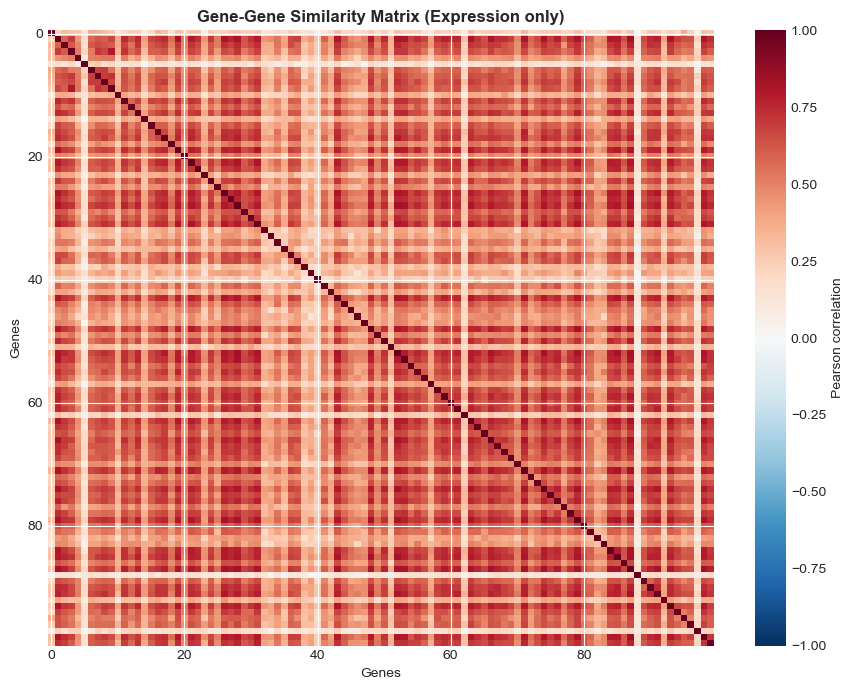

In [53]:
# -----------------------------------------------------------------------------
# Step 3 — Gene–gene similarity matrix S
#
# WGCNA starts from a symmetric similarity matrix S where
#       S[i, j] = correlation between expression of gene i and gene j
# across all samples. This is the raw "co-expression" signal that the next
# steps (soft-threshold, TOM, clustering) progressively refine into modules.
#
# Pearson is the default; on real RNA-seq, the WGCNA package uses bicor
# (biweight midcorrelation) instead — it is robust to outlier samples.
# -----------------------------------------------------------------------------
print("Computing Gene-Gene Similarity Matrix")
print("="*50)

S = expr_data.corr(method='pearson')                  # genes x genes
print(f"Similarity matrix shape: {S.shape}")
print(f"Correlation range: [{S.min().min():.3f}, {S.max().max():.3f}]")

# Visualise — should look mostly red/blue blocks if any biology is there
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(S, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_title('Gene-Gene Similarity Matrix (Expression only)', fontweight='bold')
ax.set_xlabel('Genes'); ax.set_ylabel('Genes')
plt.colorbar(im, label='Pearson correlation')
plt.tight_layout()
plt.show()


---
## Step 4: Choose Soft-Thresholding Power (beta)

Pick the smallest beta that yields approximate scale-free topology
(R² ≥ 0.8) so that hub genes carry disproportionately more connections
— a hallmark of biological networks.

Selecting Soft-Thresholding Power
Found power with R^2 >= 0.8
Selected power: beta = 4
R-squared at selected power: 1.000


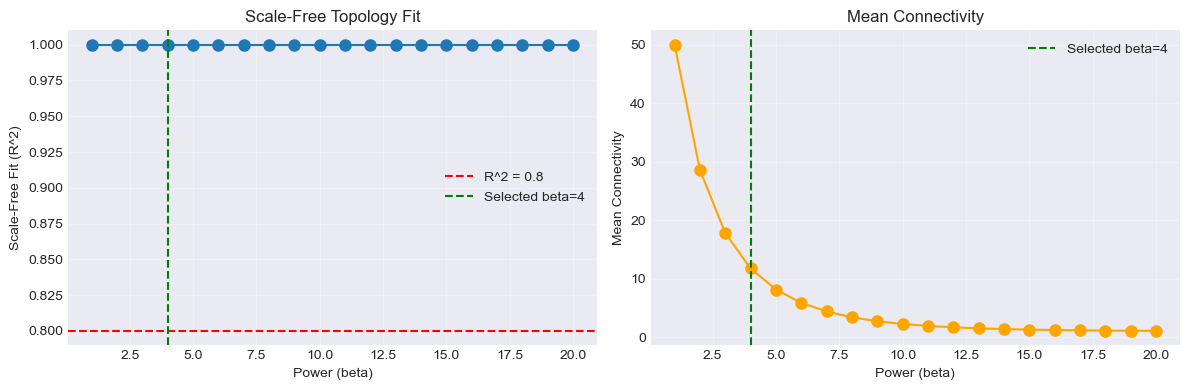

In [54]:
# -----------------------------------------------------------------------------
# Step 4 — Pick the soft-thresholding power β
#
# WGCNA converts correlations into network adjacencies via:
#       a_ij = |cor(i, j)|^β
# Higher β crushes weak correlations toward 0 while leaving strong ones near 1.
# This sparsifies the network so a power-law (scale-free) degree distribution
# can emerge — a hallmark of biological networks (few hubs, many leaves).
#
# Selection rule: smallest β with R² ≥ 0.8 of the log-log fit P(k) ~ k^(-γ).
# If no β reaches 0.8, fall back to 6 (unsigned default) or 12 (signed default).
# -----------------------------------------------------------------------------
print("Selecting Soft-Thresholding Power")
print("="*50)

powers = range(1, 21)
results = []

# Scan β = 1..20, computing scale-free fit at each value
for beta in powers:
    # Adjacency at this β
    A_b = np.abs(S.values) ** beta

    # Node connectivity k_i = sum of edge weights on node i
    k = A_b.sum(axis=1)

    # Build empirical degree distribution P(k) and fit log-log line
    k_unique, k_counts = np.unique(k[k > 0], return_counts=True)
    if len(k_unique) >= 3:
        log_k = np.log10(k_unique).reshape(-1, 1)
        log_pk = np.log10(k_counts)
        model = LinearRegression().fit(log_k, log_pk)
        r_sq = model.score(log_k, log_pk)
    else:
        r_sq = 0  # too few unique k values for a meaningful fit
    results.append({'Power': beta, 'R_squared': r_sq, 'Mean_k': k.mean()})

sft_df = pd.DataFrame(results)

# Apply selection rule: first β with both R² ≥ 0.8 and reasonable connectivity
good = sft_df[(sft_df['R_squared'] >= 0.8) & (sft_df['Power'] >= 4)]
if len(good) > 0:
    beta_optimal = int(good.iloc[0]['Power'])
    print("Found power with R^2 >= 0.8")
else:
    beta_optimal = 6
    print("Using default power=6 (standard for unsigned networks)")

print(f"Selected power: beta = {beta_optimal}")
print(f"R-squared at selected power: "
      f"{sft_df[sft_df['Power']==beta_optimal]['R_squared'].values[0]:.3f}")

# Two diagnostic plots:
#   left  — scale-free fit R² (we want this ≥ 0.8)
#   right — mean connectivity (we don't want it collapsing toward 0)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(sft_df['Power'], sft_df['R_squared'], 'o-', markersize=8)
ax1.axhline(y=0.8, color='red', linestyle='--', label='R^2 = 0.8')
ax1.axvline(x=beta_optimal, color='green', linestyle='--',
            label=f'Selected beta={beta_optimal}')
ax1.set_xlabel('Power (beta)'); ax1.set_ylabel('Scale-Free Fit (R^2)')
ax1.set_title('Scale-Free Topology Fit'); ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(sft_df['Power'], sft_df['Mean_k'], 'o-', color='orange', markersize=8)
ax2.axvline(x=beta_optimal, color='green', linestyle='--',
            label=f'Selected beta={beta_optimal}')
ax2.set_xlabel('Power (beta)'); ax2.set_ylabel('Mean Connectivity')
ax2.set_title('Mean Connectivity'); ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()


---
## Step 5: Build Adjacency and TOM Matrices

In [55]:
# -----------------------------------------------------------------------------
# Step 5a — Adjacency matrix:   A[i, j] = |S[i, j]|^β
#
# This is the core WGCNA non-linear filter: weak correlations approach 0 and
# strong correlations stay near 1. The matrix is symmetric, dense, and
# represents a weighted (rather than binary) network.
# -----------------------------------------------------------------------------
print(f"Building Adjacency Matrix (beta={beta_optimal})")
print("="*50)

A = pd.DataFrame(
    np.abs(S.values) ** beta_optimal,
    index=S.index, columns=S.columns,
)
print(f"Adjacency matrix shape: {A.shape}")
print(f"Adjacency range: [{A.min().min():.6f}, {A.max().max():.6f}]")


Building Adjacency Matrix (beta=4)
Adjacency matrix shape: (100, 100)
Adjacency range: [0.000000, 1.000000]


In [56]:
# -----------------------------------------------------------------------------
# Step 5b — Topological Overlap Matrix (TOM)
#
# TOM strengthens the signal by counting SHARED NEIGHBOURS, not just direct
# correlation. Two genes get a high TOM score if they are not only correlated
# with each other but ALSO correlated with the same set of other genes —
# which is exactly what defines a co-regulated module in biology.
#
# Formula (unsigned WGCNA):
#       L[i, j]  = sum over k of  A[i, k] * A[j, k]      (matrix product A·A)
#       TOM[i,j] = (L[i, j] + A[i, j]) / (min(k_i, k_j) + 1 - A[i, j])
#       TOM[i,i] = 1
#
# We then turn TOM into a DISSIMILARITY (1 - TOM) so we can feed it to a
# distance-based clustering routine.
# -----------------------------------------------------------------------------
print("Computing Topological Overlap Matrix (TOM)")
print("="*50)

A_np = A.values
n = A_np.shape[0]
k = A_np.sum(axis=1)        # node connectivity vector
L = A_np @ A_np             # shared-neighbour matrix (matrix product)

# Vectorised TOM — equivalent to nested loops but ~100x faster.
k_min = np.minimum.outer(k, k)             # min(k_i, k_j) for every (i, j)
denom = k_min + 1 - A_np
with np.errstate(divide='ignore', invalid='ignore'):
    TOM = np.where(denom > 0, (L + A_np) / denom, 0.0)
np.fill_diagonal(TOM, 1.0)                 # a node always overlaps fully with itself

TOM = pd.DataFrame(TOM, index=A.index, columns=A.columns)
dissTOM = 1 - TOM                          # used by hierarchical clustering
print(f"TOM computed: shape {TOM.shape}")
print("TOM dissimilarity computed")


Computing Topological Overlap Matrix (TOM)
TOM computed: shape (100, 100)
TOM dissimilarity computed


---
## Step 6: Hierarchical Clustering and Module Identification

In [57]:
# -----------------------------------------------------------------------------
# Step 6a — Hierarchical clustering on TOM dissimilarity
#
# Average linkage (UPGMA) is the WGCNA default — it produces balanced,
# biologically interpretable trees. The output `tree` is a SciPy linkage
# matrix that the next cell will cut into modules.
# -----------------------------------------------------------------------------
print("Performing Hierarchical Clustering")
print("="*50)

# scipy's linkage expects a "condensed" (1-D upper-triangular) distance vector
dissTOM_condensed = squareform(dissTOM, checks=False)

# Average linkage = unweighted pair-group method with arithmetic mean (UPGMA)
tree = linkage(dissTOM_condensed, method='average')
print(f"Clustering complete: {len(dissTOM.columns)} genes")


Performing Hierarchical Clustering
Clustering complete: 100 genes


In [58]:
# -----------------------------------------------------------------------------
# Step 6b — Cut the dendrogram into gene modules
#
# In a real WGCNA pipeline, modules are found with `cutreeDynamic` (an
# adaptive, branch-by-branch tree cut). For a teaching notebook we use the
# simpler `fcluster(..., criterion='maxclust')`, which gives a deterministic
# partition into a target number of clusters.
#
# Two parameters drive everything:
#   * n_target_modules — initial number of clusters to extract
#   * min_module_size  — clusters smaller than this are merged into the
#                        special "grey" module 0 (= unassigned). This matches
#                        WGCNA convention, where the grey bucket holds genes
#                        that did not co-cluster with anything robust.
#
# Only non-grey modules are carried forward to eigengene + mQTL analysis.
# -----------------------------------------------------------------------------
print("Identifying Modules")
print("="*50)

n_target_modules = 6      # tune for your dataset
min_module_size  = 5      # WGCNA convention: drop tiny clusters into 'grey'

tree_heights = tree[:, 2]
print(f"Tree height range: {tree_heights.min():.3f} to {tree_heights.max():.3f}")

# Initial cut: produce up to n_target_modules clusters
labels_initial = fcluster(tree, t=n_target_modules, criterion='maxclust')
sizes = pd.Series(labels_initial).value_counts()
print(f"Initial clusters from maxclust: {len(sizes)}, sizes: {sorted(sizes.tolist(), reverse=True)}")

# Step 1: keep only clusters with enough genes; everything else → 0 (grey)
keep = set(sizes[sizes >= min_module_size].index)
filtered = np.where(np.isin(labels_initial, list(keep)), labels_initial, 0)

# Step 2: renumber retained modules to a clean 1..N space (0 stays = grey)
unique_keep = sorted(set(filtered) - {0})
remap = {old: new for new, old in enumerate(unique_keep, start=1)}
remap[0] = 0
final_labels = np.array([remap[l] for l in filtered])

n_real_modules = len(unique_keep)
n_grey = (final_labels == 0).sum()
print(f"After min_module_size={min_module_size} filter: "
      f"{n_real_modules} retained modules, {n_grey} genes in 'grey' (unassigned)")

# WGCNA labels modules with colours rather than numbers — purely a convention
# but it makes downstream plots easier to talk about.
module_colors = ['grey', 'turquoise', 'blue', 'brown', 'yellow', 'green',
                 'red', 'black', 'pink', 'magenta', 'purple', 'orange']

module_assignment = pd.DataFrame({
    'Gene':        dissTOM.columns.tolist(),
    'ModuleNum':   final_labels,
    'ModuleColor': [module_colors[i % len(module_colors)] for i in final_labels],
})

# Print one line per module so we can spot pathological cases (e.g. a single
# huge module or many singletons).
print("\nModule sizes:")
for mod in sorted(module_assignment['ModuleNum'].unique()):
    sub = module_assignment[module_assignment['ModuleNum'] == mod]
    color = sub['ModuleColor'].iloc[0]
    tag = '  (unassigned)' if mod == 0 else ''
    print(f"  Module {mod} ({color}): {len(sub)} genes{tag}")

# Educational note for this synthetic dataset
if n_real_modules <= 1:
    print("\nNote: this synthetic dataset has a single dominant co-expression block")
    print("(mean pairwise r ≈ 0.5, no negative correlations). Real RNA-seq")
    print("studies typically yield 5-20 modules. The mQTL workflow below still")
    print("applies, but with only one module the demonstration is condensed.")


Identifying Modules
Tree height range: 0.622 to 0.996
Initial clusters from maxclust: 6, sizes: [95, 1, 1, 1, 1, 1]
After min_module_size=5 filter: 1 retained modules, 5 genes in 'grey' (unassigned)

Module sizes:
  Module 0 (grey): 5 genes  (unassigned)
  Module 1 (turquoise): 95 genes

Note: this synthetic dataset has a single dominant co-expression block
(mean pairwise r ≈ 0.5, no negative correlations). Real RNA-seq
studies typically yield 5-20 modules. The mQTL workflow below still
applies, but with only one module the demonstration is condensed.


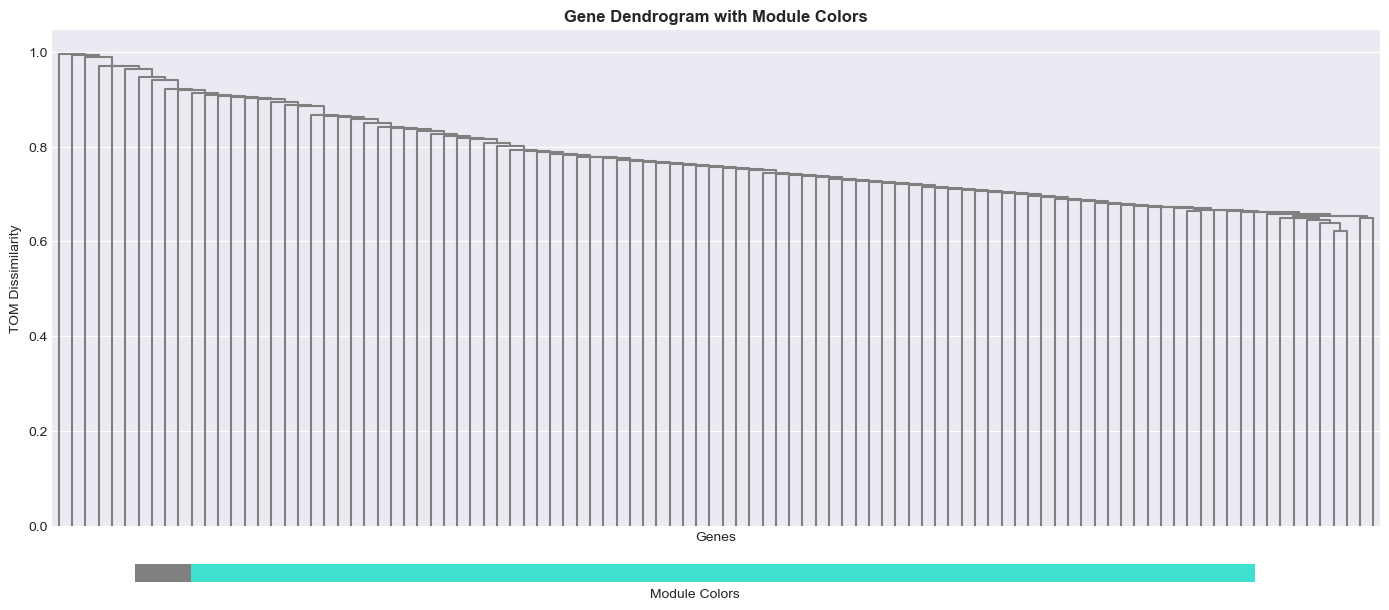

In [59]:
# -----------------------------------------------------------------------------
# Step 6c — Visualise the gene dendrogram with module colours
#
# Two stacked panels:
#   * top    — the dendrogram itself (TOM dissimilarity on y-axis)
#   * bottom — a coloured strip aligned with leaves, one colour per module
#
# This is the iconic WGCNA "cluster dendrogram with module colors" plot.
# -----------------------------------------------------------------------------
import matplotlib.colors as mcolors
from matplotlib.patches import Rectangle

fig, ax = plt.subplots(figsize=(14, 6))

# Plot the dendrogram first (no leaf labels — there can be thousands of genes)
dendro = dendrogram(
    tree,
    labels=dissTOM.columns.tolist(),
    ax=ax,
    color_threshold=0,
    above_threshold_color='gray',
    no_labels=True,
)
ax.set_title('Gene Dendrogram with Module Colors', fontsize=12, fontweight='bold')
ax.set_xlabel('Genes')
ax.set_ylabel('TOM Dissimilarity')

# Add a thin coloured strip below the dendrogram showing the module of each leaf.
# `dendro['leaves']` is the leaf order chosen by SciPy; we read off the module
# colour for each gene in that exact order.
ax2 = fig.add_axes([0.1, 0.02, 0.8, 0.03])
gene_order = [dissTOM.columns[i] for i in dendro['leaves']]
colors_ordered = [
    module_assignment.loc[module_assignment['Gene'] == g, 'ModuleColor'].iloc[0]
    for g in gene_order
]
for idx, col in enumerate(colors_ordered):
    try:
        rgb = mcolors.to_rgb(col)
    except ValueError:
        rgb = (0.5, 0.5, 0.5)                        # fall back to grey on bad colour names
    ax2.add_patch(Rectangle((idx, 0), 1, 1, facecolor=rgb, edgecolor='none'))

ax2.set_xlim(0, len(colors_ordered)); ax2.set_ylim(0, 1)
ax2.set_xticks([]); ax2.set_yticks([])
ax2.set_xlabel('Module Colors')

plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()


---
## Step 7: Module Eigengenes — the Quantitative Phenotypes

For each module, the eigengene is the first principal component of its member
genes. It is the **summary expression profile** of the module across samples.

These eigengenes are the bridge to the next step: each one becomes a
quantitative trait on which we will run mQTL.

In [60]:
# -----------------------------------------------------------------------------
# Step 7 — Module eigengenes (ME)
#
# A module is summarised by its FIRST PRINCIPAL COMPONENT across samples:
#       ME_m = PC1 of the (samples x genes_in_module) sub-matrix
# This single vector captures the dominant co-expression pattern of the module
# and becomes a "synthetic phenotype" (a quantitative trait) that we can:
#   * correlate with clinical phenotypes (Step 8)
#   * regress against SNP genotypes — mQTL (Step 9)
#   * use to identify hub genes — kME / GS (Step 10)
#
# IMPORTANT: PCA sign is arbitrary. We FLIP PC1 to align with the module's
# mean expression so a "high ME" sample is one where the module is "ON".
# Without this convention, half the modules would have their interpretation
# inverted relative to the gene panel.
# -----------------------------------------------------------------------------
print("Computing Module Eigengenes")
print("="*50)

ME_dict = {}      # module-name -> eigengene vector (length = n_samples)
ME_var  = {}      # module-name -> fraction of variance explained by PC1

for mod in sorted(module_assignment['ModuleNum'].unique()):
    if mod == 0:
        continue                                        # skip grey/unassigned

    # Genes belonging to this module
    genes = module_assignment.loc[module_assignment['ModuleNum'] == mod, 'Gene'].tolist()
    color = module_assignment.loc[module_assignment['ModuleNum'] == mod, 'ModuleColor'].iloc[0]
    module_data = expr_data[genes]                       # samples x genes_in_module

    if len(genes) == 1:
        # Edge case: a single-gene module — the eigengene IS the gene
        ME_dict[f'ME{mod}'] = module_data.iloc[:, 0].values
        ME_var[f'ME{mod}']  = 1.0
        print(f"  Module {mod} ({color}): {len(genes)} gene (no PCA needed)")
    else:
        # PC1 across samples
        pca = PCA(n_components=1)
        pc1 = pca.fit_transform(module_data).flatten()

        # Sign convention: if PC1 anti-correlates with mean expression, flip it
        # so 'high ME' = 'high module activity'. This is what WGCNA does too.
        if np.corrcoef(pc1, module_data.mean(axis=1))[0, 1] < 0:
            pc1 = -pc1

        ME_dict[f'ME{mod}'] = pc1
        ME_var[f'ME{mod}']  = pca.explained_variance_ratio_[0]
        print(f"  Module {mod} ({color}): {len(genes)} genes, "
              f"PC1 variance = {ME_var[f'ME{mod}']:.1%}")

ME_df = pd.DataFrame(ME_dict, index=expr_data.index)
print(f"\nModule eigengenes: {ME_df.shape}  — each column is now a quantitative trait.")


Computing Module Eigengenes
  Module 1 (turquoise): 95 genes, PC1 variance = 55.6%

Module eigengenes: (300, 1)  — each column is now a quantitative trait.


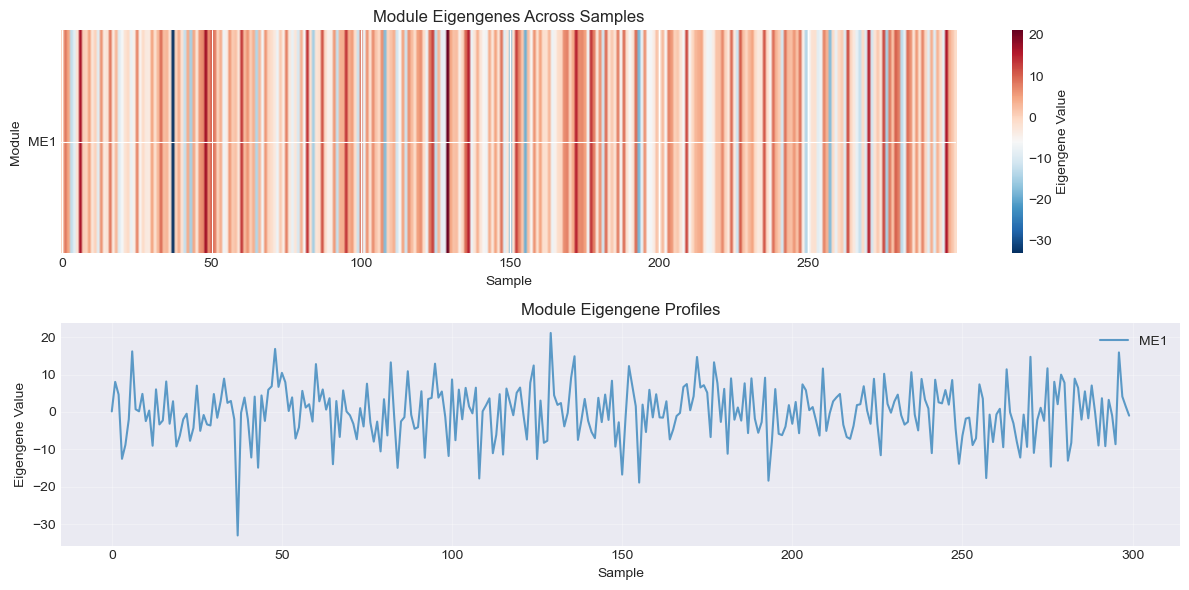

In [61]:
# -----------------------------------------------------------------------------
# Visualise module eigengenes
#
#   top    — heat-map: rows=modules, cols=samples, colour=eigengene value
#            Useful to spot subgroups of samples that share the same module-on/off pattern.
#   bottom — line plot: each module's eigengene as a sample-by-sample profile.
#            Useful for spotting outlier samples or batch effects.
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(12, 6))

# Heat-map (modules x samples)
im = axes[0].imshow(ME_df.T, aspect='auto', cmap='RdBu_r')
axes[0].set_yticks(range(len(ME_df.columns)))
axes[0].set_yticklabels(ME_df.columns)
axes[0].set_xlabel('Sample'); axes[0].set_ylabel('Module')
axes[0].set_title('Module Eigengenes Across Samples')
plt.colorbar(im, ax=axes[0], label='Eigengene Value')

# Line plot — one curve per module
for col in ME_df.columns:
    axes[1].plot(ME_df[col].values, label=col, alpha=0.7)
axes[1].set_xlabel('Sample'); axes[1].set_ylabel('Eigengene Value')
axes[1].set_title('Module Eigengene Profiles')
axes[1].legend(loc='upper right', ncol=len(ME_df.columns))
axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()


### Note on PCA in WGCNA

PCA is computed **per module** — that is the correct, canonical WGCNA approach.
A module's first principal component summarises the dominant co-expression pattern
of just *that* gene set, and the resulting vector becomes the **module eigengene**
that is fed to module–trait correlations and mQTL.

To complement this, the cell below runs a **single global PCA on all genes** and
plots each gene in (PC1, PC2) space coloured by its module. If the modules are
real biology, genes from the same module should cluster together in this plot —
a visual sanity check on the WGCNA partition.

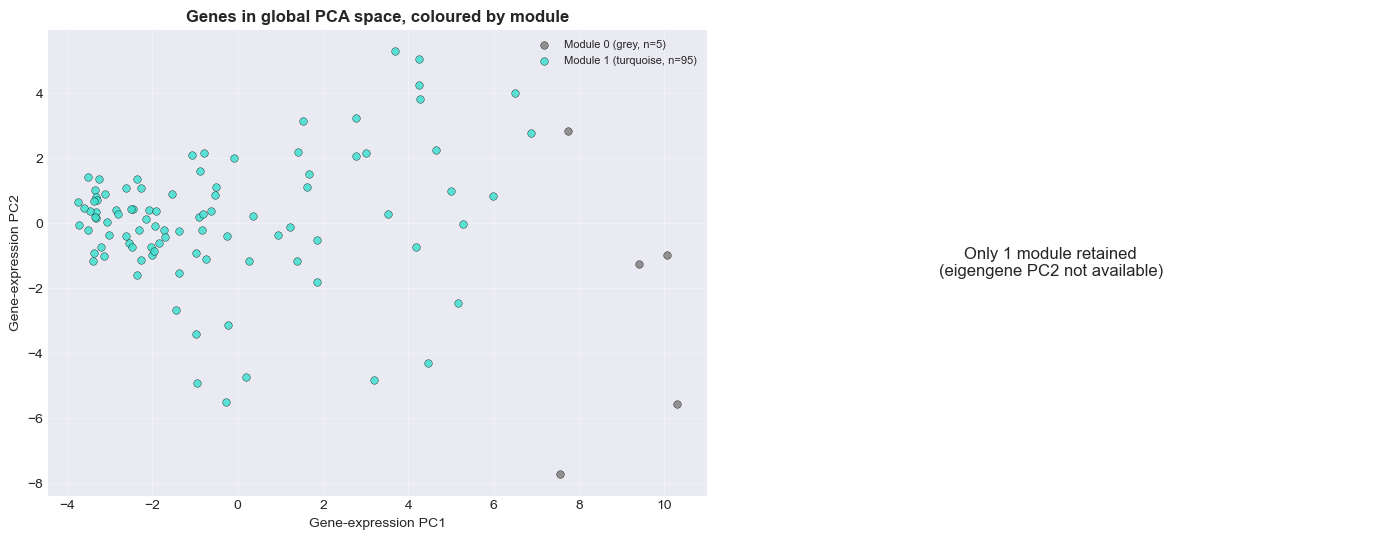

Saved: ../data/ASD_dataset/WGCNA_modules_PCA.png


In [62]:
# -----------------------------------------------------------------------------
# Visualise modules in a SHARED PCA space
#
# Per-module PCA (above) gives one eigengene per module — that is correct WGCNA.
# Here we additionally run a SINGLE global PCA where the observations are
# genes (rows of expr_data.T) and the features are samples. This places every
# gene at one point in (PC1, PC2) space; we colour it by its assigned module.
#
# Why bother?
#   * If WGCNA modules reflect real co-expression, genes from the same module
#     should sit close together in this global space.
#   * It is a fast visual cross-check on the dendrogram-based partition.
#
# Two panels:
#   left   — gene scatter PC1 vs PC2 (each point = a gene, coloured by module)
#   right  — sample scatter PC1 vs PC2 in EIGENGENE space (each point = a
#            sample), coloured by ASD case/control. This shows whether the
#            module-summary representation separates the phenotype.
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# ---------------- Left: genes in expression PC1-PC2, coloured by module ------
# Observations = genes; features = samples. PCA finds the directions in
# sample-space along which gene expression varies most.
gene_pca = PCA(n_components=2).fit_transform(expr_data.T.values)

# Build the gene -> colour mapping from the WGCNA assignment table
gene_color = module_assignment.set_index('Gene')['ModuleColor']
colors_for_plot = gene_color.reindex(expr_data.columns).fillna('grey').values

ax = axes[0]
# One scatter call per module so the legend lists modules cleanly
for color, sub in module_assignment.groupby('ModuleColor'):
    idx = expr_data.columns.get_indexer(sub['Gene'])
    label = (f"Module {int(sub['ModuleNum'].iloc[0])} "
             f"({color}, n={len(sub)})")
    ax.scatter(gene_pca[idx, 0], gene_pca[idx, 1],
               s=30, c=color, label=label,
               edgecolor='k', linewidth=0.3, alpha=0.85)

ax.set_xlabel('Gene-expression PC1')
ax.set_ylabel('Gene-expression PC2')
ax.set_title('Genes in global PCA space, coloured by module', fontweight='bold')
ax.legend(loc='best', fontsize=8)
ax.grid(True, alpha=0.3)

# ---------------- Right: samples in eigengene PC1-PC2, coloured by phenotype -
# Observations = samples; features = the module eigengenes.
# This shows whether the (small!) eigengene representation captures phenotype.
ax = axes[1]
if ME_df.shape[1] >= 2:
    sample_pca = PCA(n_components=2).fit_transform(ME_df.values)

    # Colour samples by ASD (1) vs Control (0)
    if 'ASD' in covariates.columns:
        is_case = covariates['ASD'].reindex(ME_df.index).fillna(0).astype(int).values
        for label, mask, color in [('Control', is_case == 0, '#4c78a8'),
                                   ('ASD',     is_case == 1, '#e45756')]:
            ax.scatter(sample_pca[mask, 0], sample_pca[mask, 1],
                       s=22, c=color, label=label,
                       edgecolor='k', linewidth=0.2, alpha=0.85)
        ax.legend(loc='best', fontsize=9)
    else:
        ax.scatter(sample_pca[:, 0], sample_pca[:, 1], s=22, alpha=0.85)

    ax.set_xlabel('Eigengene PC1')
    ax.set_ylabel('Eigengene PC2')
    ax.set_title('Samples in eigengene PCA space (ASD vs Control)', fontweight='bold')
    ax.grid(True, alpha=0.3)
else:
    # With only one module there is no second eigengene to plot against.
    ax.text(0.5, 0.5,
            'Only 1 module retained\n(eigengene PC2 not available)',
            ha='center', va='center', fontsize=12,
            transform=ax.transAxes)
    ax.set_axis_off()

plt.tight_layout()
plt.savefig('../data/ASD_dataset/WGCNA_modules_PCA.png',
            dpi=300, bbox_inches='tight')
plt.show()
print("Saved: ../data/ASD_dataset/WGCNA_modules_PCA.png")

---
## Step 8: Relate Modules to Clinical Traits

A first sanity check: do any modules track clinical phenotypes?
This is the standard WGCNA "module–trait" heatmap.

Computing Module-Trait Correlations
Module-Trait Correlations:
       ASD    Age    Sex     IQ  ADOS_Score
ME1 -0.078  0.029  0.023 -0.013      -0.033


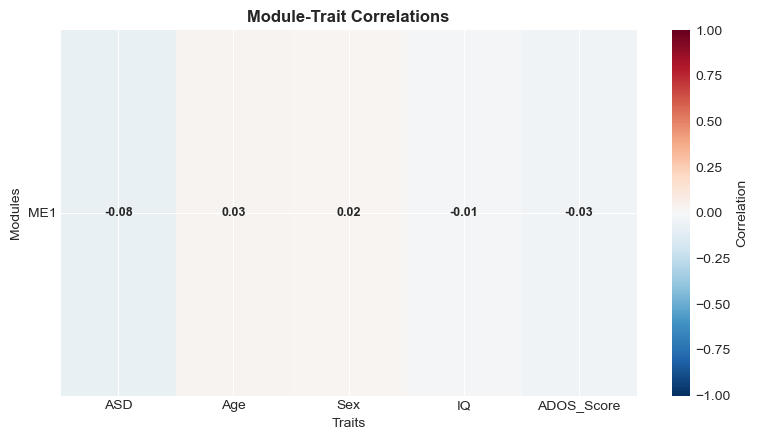

In [63]:
# -----------------------------------------------------------------------------
# Step 8 — Relate modules to clinical traits
#
# Compute Pearson correlation between every module eigengene (column of ME_df)
# and every clinical phenotype (column of `traits`). The resulting heatmap is
# the canonical WGCNA "module-trait" plot — it tells you which co-expression
# program (= module) tracks which clinical variable.
#
# We also store the p-values so the heat-map can show significance stars
# (* p<0.05, ** p<0.01, *** p<0.001).
# -----------------------------------------------------------------------------
print("Computing Module-Trait Correlations")
print("="*50)

traits = covariates[['ASD', 'Age', 'Sex', 'IQ', 'ADOS_Score']].copy()

# Two parallel matrices: r and p, both (modules x traits)
corr_data, pval_data = [], []
for module in ME_df.columns:
    corr_row, pval_row = {}, {}
    for trait in traits.columns:
        valid = ~traits[trait].isna()                       # ignore missing values
        if valid.sum() > 0:
            r, p = stats.pearsonr(ME_df.loc[valid, module], traits.loc[valid, trait])
            corr_row[trait], pval_row[trait] = r, p
        else:
            corr_row[trait], pval_row[trait] = np.nan, np.nan
    corr_data.append(corr_row); pval_data.append(pval_row)

trait_corr = pd.DataFrame(corr_data, index=ME_df.columns)
trait_pval = pd.DataFrame(pval_data, index=ME_df.columns)

print("Module-Trait Correlations:")
print(trait_corr.round(3))

# Heatmap with annotated cells (r value + significance stars)
fig, ax = plt.subplots(figsize=(8, 4.5))
im = ax.imshow(trait_corr.astype(float), cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_yticks(range(len(trait_corr.index)));   ax.set_yticklabels(trait_corr.index)
ax.set_xticks(range(len(trait_corr.columns))); ax.set_xticklabels(trait_corr.columns)
ax.set_title('Module-Trait Correlations', fontweight='bold')
ax.set_xlabel('Traits'); ax.set_ylabel('Modules')

for i in range(len(trait_corr.index)):
    for j in range(len(trait_corr.columns)):
        r = trait_corr.iloc[i, j]; p = trait_pval.iloc[i, j]
        if pd.notna(p):
            # Standard star convention used in genomics papers
            stars = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
            ax.text(j, i, f'{r:.2f}{stars}', ha='center', va='center',
                    fontsize=9, fontweight='bold')

plt.colorbar(im, ax=ax, label='Correlation')
plt.tight_layout()
plt.savefig('../data/ASD_dataset/WGCNA_module_trait.png', dpi=300, bbox_inches='tight')
plt.show()


---
## Step 9: mQTL — Map Genotypes to Modules

This is the **key multi-omics step**. Each module eigengene `ME_k` is now a
continuous quantitative trait derived from co-expression. For every SNP `j`
(allele dosage 0/1/2) we fit:

$$ME_k = \beta \cdot SNP_j + \varepsilon$$

The slope $\beta$ and its p-value give the **module-QTL effect**: how much
each variant shifts the activity of the entire co-expression module.
Significant mQTLs identify variants that drive coordinated transcriptomic
programs — a much stronger signal than per-gene eQTL when modules represent
real biology.

**Multiple testing**: with K modules and S SNPs we run K·S tests; we report
both Bonferroni and Benjamini–Hochberg FDR.

In [64]:
# -----------------------------------------------------------------------------
# Step 9 — mQTL: regress every SNP against every module eigengene
#
# This is THE multi-omics step. Each module eigengene is now a continuous
# quantitative trait derived from co-expression. For every SNP j we fit the
# simple linear model:
#       ME_k = β · SNP_j + ε
# where SNP_j is the dosage in {0, 1, 2}. The slope β is interpretable as
# "change in eigengene per copy of the alt allele". Significant mQTLs reveal
# variants that drive whole co-expression PROGRAMMES, not single genes.
#
# We control multiple testing in two complementary ways:
#   * Bonferroni  — strict family-wise error rate (FWER)
#   * BH-FDR      — false-discovery rate (more powerful, less strict)
# -----------------------------------------------------------------------------
print("Running mQTL: SNPs vs Module Eigengenes")
print("="*50)

# Re-align indices: only test on samples present in BOTH tables
samples_xt   = ME_df.index.intersection(genotypes.index)
ME_aligned   = ME_df.loc[samples_xt]
geno_aligned = genotypes.loc[samples_xt]

n_modules = ME_aligned.shape[1]
n_snps    = geno_aligned.shape[1]
print(f"Tests: {n_modules} modules x {n_snps} SNPs = {n_modules * n_snps}")

# One linear regression per (module, SNP) pair
mqtl_results = []
for module in ME_aligned.columns:
    y = ME_aligned[module].values
    for snp in geno_aligned.columns:
        x = geno_aligned[snp].values.astype(float)
        if np.unique(x).size < 2:
            continue                                      # monomorphic — skip
        # scipy.stats.linregress returns slope, intercept, r, p, std_err
        slope, intercept, r, p, se = stats.linregress(x, y)
        mqtl_results.append({
            'Module':  module, 'SNP':    snp,
            'beta':    slope,  'SE':     se,
            'r':       r,      'pvalue': p,
            'n':       len(x),
        })

mqtl_df = pd.DataFrame(mqtl_results)

# ----- Multiple testing correction --------------------------------------------
# Bonferroni: simply multiply each p-value by m (capped at 1.0).
# It controls FWER but is conservative when tests are correlated.
m = len(mqtl_df)
mqtl_df['p_bonferroni'] = (mqtl_df['pvalue'] * m).clip(upper=1.0)

# Benjamini–Hochberg FDR:
#   1. Sort tests by p-value (ascending)
#   2. fdr_i = p_i * m / rank_i
#   3. Enforce non-decreasing FDR going down the sorted list (cumulative min from below)
mqtl_df = mqtl_df.sort_values('pvalue').reset_index(drop=True)
mqtl_df['fdr_bh'] = (mqtl_df['pvalue'] * m / (mqtl_df.index + 1)).clip(upper=1.0)
mqtl_df['fdr_bh'] = mqtl_df['fdr_bh'][::-1].cummin()[::-1]

# ----- Reporting --------------------------------------------------------------
print(f"\nTotal mQTL tests:  {m}")
print(f"Nominal p < 0.05:  {(mqtl_df['pvalue'] < 0.05).sum()}")
print(f"FDR < 0.10:        {(mqtl_df['fdr_bh'] < 0.10).sum()}")
print(f"Bonferroni < 0.05: {(mqtl_df['p_bonferroni'] < 0.05).sum()}")

print("\nTop 10 mQTL associations:")
print(mqtl_df.head(10)[['Module', 'SNP', 'beta', 'SE', 'pvalue',
                        'fdr_bh', 'p_bonferroni']]
      .to_string(index=False, float_format=lambda x: f'{x:.4g}'))

mqtl_df.to_csv('../data/ASD_dataset/WGCNA_mQTL_results.csv', index=False)
print("\nSaved: ../data/ASD_dataset/WGCNA_mQTL_results.csv")


Running mQTL: SNPs vs Module Eigengenes
Tests: 1 modules x 50 SNPs = 50

Total mQTL tests:  50
Nominal p < 0.05:  2
FDR < 0.10:        0
Bonferroni < 0.05: 0

Top 10 mQTL associations:
Module    SNP    beta     SE  pvalue  fdr_bh  p_bonferroni
   ME1 snp_48  -1.611 0.7061 0.02321   0.737             1
   ME1  snp_4  -2.504  1.145 0.02948   0.737             1
   ME1 snp_46 -0.9498 0.5986  0.1136  0.8856             1
   ME1 snp_37   1.045 0.7523  0.1657  0.8856             1
   ME1 snp_11 -0.8962 0.6452  0.1658  0.8856             1
   ME1 snp_28  -1.035 0.7751   0.183  0.8856             1
   ME1 snp_13 -0.9783 0.7636  0.2011  0.8856             1
   ME1 snp_12 -0.8092 0.6392  0.2065  0.8856             1
   ME1  snp_5   1.801  1.443  0.2131  0.8856             1
   ME1 snp_39  0.9637  0.852  0.2589  0.8856             1

Saved: ../data/ASD_dataset/WGCNA_mQTL_results.csv


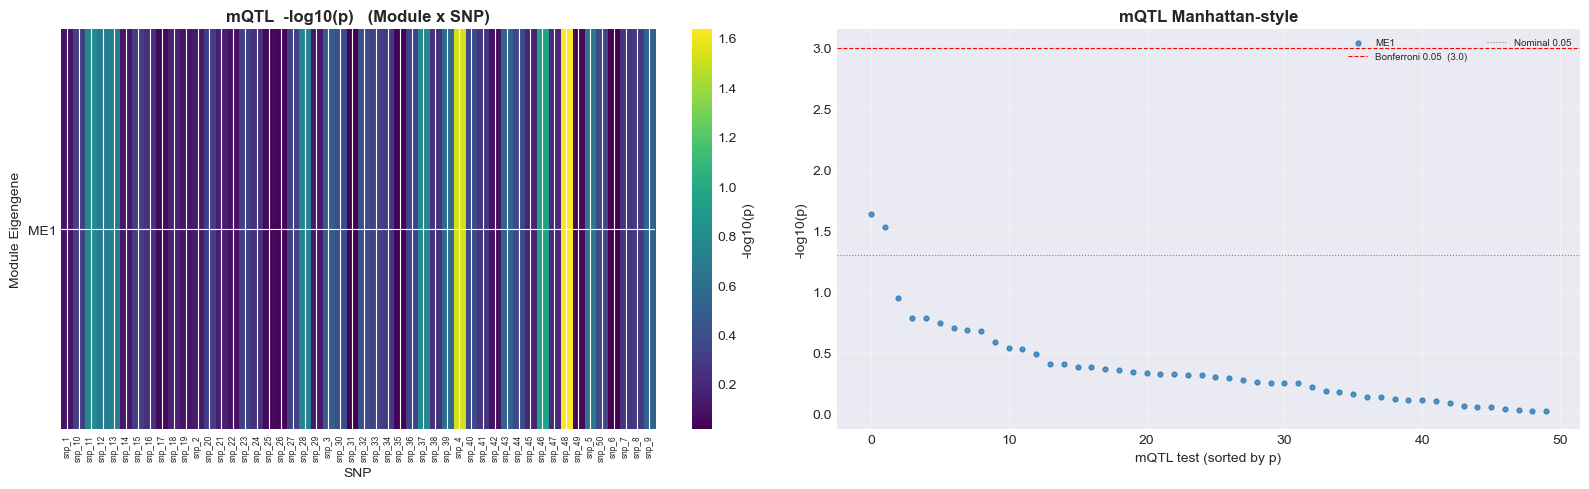

In [65]:
# -----------------------------------------------------------------------------
# Visualise the mQTL landscape — two complementary views
#
#   left  — Module x SNP heat-map of -log10(p):    where do the hits cluster?
#   right — Manhattan-style scatter (sorted by p): which tests pass which threshold?
#
# Two horizontal lines on the Manhattan plot:
#   * red dashed    — Bonferroni 0.05 cut-off (very strict)
#   * gray dotted   — nominal p = 0.05 (no correction; for orientation only)
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Left: -log10(p) heatmap (Module x SNP) ---
pivot_p    = mqtl_df.pivot(index='Module', columns='SNP', values='pvalue')
pivot_logp = -np.log10(pivot_p)

ax = axes[0]
im = ax.imshow(pivot_logp.values, cmap='viridis', aspect='auto')
ax.set_yticks(range(len(pivot_logp.index)));   ax.set_yticklabels(pivot_logp.index)
ax.set_xticks(range(len(pivot_logp.columns))); ax.set_xticklabels(pivot_logp.columns,
                                                                  rotation=90, fontsize=6)
ax.set_xlabel('SNP'); ax.set_ylabel('Module Eigengene')
ax.set_title('mQTL  -log10(p)   (Module x SNP)', fontweight='bold')
plt.colorbar(im, ax=ax, label='-log10(p)')

# --- Right: Manhattan-style scatter, coloured by module ---
ax = axes[1]
plot_df = mqtl_df.copy()
plot_df['xpos'] = np.arange(len(plot_df))
palette = {m: plt.cm.tab10(i) for i, m in enumerate(plot_df['Module'].unique())}
for module, sub in plot_df.groupby('Module'):
    ax.scatter(sub['xpos'], -np.log10(sub['pvalue']),
               s=12, color=palette[module], label=module, alpha=0.75)

# Significance reference lines
sig_bonf = -np.log10(0.05 / len(plot_df))
ax.axhline(y=sig_bonf, color='red', linestyle='--', lw=0.8,
           label=f'Bonferroni 0.05  ({sig_bonf:.1f})')
ax.axhline(y=-np.log10(0.05), color='gray', linestyle=':', lw=0.8,
           label='Nominal 0.05')

ax.set_xlabel('mQTL test (sorted by p)')
ax.set_ylabel('-log10(p)')
ax.set_title('mQTL Manhattan-style', fontweight='bold')
ax.legend(loc='upper right', fontsize=7, ncol=2)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/ASD_dataset/WGCNA_mQTL_results.png', dpi=300, bbox_inches='tight')
plt.show()


Top mQTL: ME1 ~ snp_48    beta=-1.611  p=0.023  FDR=0.74


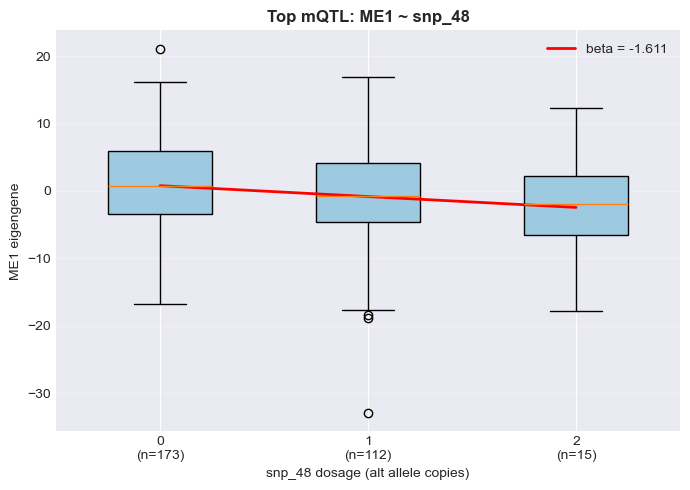

In [66]:
# -----------------------------------------------------------------------------
# Top mQTL hit — eigengene distribution by genotype
#
# A focused look at the single strongest mQTL association: a boxplot of the
# module eigengene grouped by allele dosage (0, 1, 2). A clear linear trend
# across the three boxes is exactly what an mQTL is supposed to look like.
# The red line is the regression slope on the original 0/1/2 scale.
# -----------------------------------------------------------------------------
top = mqtl_df.iloc[0]                                  # lowest p-value (already sorted)
top_module, top_snp = top['Module'], top['SNP']
print(f"Top mQTL: {top_module} ~ {top_snp}    "
      f"beta={top['beta']:.3f}  p={top['pvalue']:.2g}  FDR={top['fdr_bh']:.2g}")

x = geno_aligned[top_snp].values
y = ME_aligned[top_module].values

fig, ax = plt.subplots(figsize=(7, 5))

# Build one box per genotype that actually appears in the data
xs = np.array([0, 1, 2])
data   = [y[x == g] for g in xs if (x == g).any()]
labels = [f'{g}\n(n={len(d)})' for g, d in zip(xs, data) if len(d) > 0]

bp = ax.boxplot(data, labels=labels, patch_artist=True, widths=0.5)
for patch in bp['boxes']:
    patch.set_facecolor('#9ecae1')

# Overlay the fitted regression line
xline = np.linspace(0, 2, 100)
ax.plot(xline + 1, top['beta'] * xline + (y.mean() - top['beta'] * x.mean()),
        color='red', lw=2, label=f"beta = {top['beta']:.3f}")

ax.set_xlabel(f'{top_snp} dosage (alt allele copies)')
ax.set_ylabel(f'{top_module} eigengene')
ax.set_title(f'Top mQTL: {top_module} ~ {top_snp}', fontweight='bold')
ax.legend(loc='best')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../data/ASD_dataset/WGCNA_mQTL_topHit.png', dpi=300, bbox_inches='tight')
plt.show()


---
## Step 10: Hub-gene identification — Module Membership (kME) and Gene Significance (GS)

A **hub gene** is one that is both:

- **central in its module** — high correlation with the module eigengene
  (Module Membership, also called kME or signed eigengene-based connectivity);
- **biologically relevant** — high correlation with a trait of interest
  (Gene Significance, GS).

Plotting GS vs kME inside each module surfaces the genes in the upper-right
corner: highly connected within the module *and* aligned with the phenotype.
These are prime candidates for follow-up (functional validation, drug targets,
biomarker panels).

In [67]:
# -----------------------------------------------------------------------------
# Step 10a — Module Membership (kME)
#
# kME[gene, module] = correlation between a gene's expression and the module's
# eigengene. Conceptually:
#   * |kME| ≈ 1   → the gene is at the CORE of the module (a hub)
#   * |kME| ≈ 0   → the gene barely participates in the module
#
# kME also lets us double-check the clustering: each gene should have its
# highest |kME| in its assigned module. When that's not true for many genes,
# the cut height or merge threshold needs revisiting.
# -----------------------------------------------------------------------------
print("Computing Module Membership (kME) for every gene x every module")
print("="*60)

# Two parallel matrices: kME values and their p-values (genes x modules)
kME   = pd.DataFrame(index=expr_data.columns, columns=ME_df.columns, dtype=float)
kME_p = kME.copy()

for module in ME_df.columns:
    me_vec = ME_df[module].values
    for gene in expr_data.columns:
        r, p = stats.pearsonr(expr_data[gene].values, me_vec)
        kME.loc[gene, module]   = r
        kME_p.loc[gene, module] = p

# Convenience columns: the module each gene fits BEST (by |kME|), and
# the corresponding |kME| value. Useful for QC and hub identification.
kME['BestModule']    = kME.iloc[:, :ME_df.shape[1]].abs().idxmax(axis=1)
kME['BestModuleKME'] = kME.iloc[:, :ME_df.shape[1]].abs().max(axis=1)

# Compare with the assignment from clustering — discrepancies flag border genes
assigned = module_assignment.set_index('Gene')['ModuleNum']
kME['AssignedModuleNum'] = assigned.reindex(kME.index).values

print(f"kME matrix: {ME_df.shape[1]} modules x {len(expr_data.columns)} genes")
print(f"\nkME range across all gene-module pairs: "
      f"[{kME.iloc[:, :ME_df.shape[1]].min().min():+.3f}, "
      f"{kME.iloc[:, :ME_df.shape[1]].max().max():+.3f}]")

print("\nTop 5 most centrally-connected genes per module (highest |kME|):")
for module in ME_df.columns:
    top = kME[module].abs().sort_values(ascending=False).head(5)
    print(f"  {module}: " + ", ".join(f"{g}({kME.loc[g, module]:+.2f})"
                                      for g in top.index))


Computing Module Membership (kME) for every gene x every module
kME matrix: 1 modules x 100 genes

kME range across all gene-module pairs: [+0.174, +0.921]

Top 5 most centrally-connected genes per module (highest |kME|):
  ME1: DRD2(+0.92), TSC2(+0.91), SCN1A(+0.91), CAMK2B(+0.91), CDH2(+0.90)


In [68]:
# -----------------------------------------------------------------------------
# Step 10b — Gene Significance (GS) and combined hub score
#
# GS[gene] = correlation between a gene's expression and the trait of interest.
# A "hub gene" candidate is one that is:
#   * central in its module          → high |kME|
#   * relevant to the phenotype      → high |GS|
# We rank genes by |kME| × |GS| (a simple multiplicative score) to surface
# candidates worth functional follow-up.
# -----------------------------------------------------------------------------
print("Computing Gene Significance (GS) and ranking hub candidates")
print("="*60)

# Choose the primary trait. In a real study this is the disease/exposure
# of interest; here we default to ASD case/control.
trait_of_interest = 'ASD' if 'ASD' in covariates.columns else covariates.columns[0]
trait_vec = covariates[trait_of_interest].astype(float)
print(f"Trait of interest: {trait_of_interest}")

# Per-gene Pearson correlation with the trait
gs_rows = []
for gene in expr_data.columns:
    valid = ~trait_vec.isna()
    r, p = stats.pearsonr(expr_data.loc[valid, gene], trait_vec.loc[valid])
    gs_rows.append({'Gene': gene, 'GS': r, 'GS_pvalue': p, 'absGS': abs(r)})
GS = pd.DataFrame(gs_rows).set_index('Gene')

# Build the hub table: every gene gets its assigned-module kME and its GS
hub_table = pd.DataFrame({
    'Gene':              expr_data.columns,
    'AssignedModuleNum': assigned.reindex(expr_data.columns).values,
})
hub_table['AssignedModule'] = hub_table['AssignedModuleNum'].apply(
    lambda m: f'ME{int(m)}' if pd.notna(m) and m != 0 else 'grey'
)

# Look up each gene's kME in its OWN module (not its best module — small but
# meaningful difference, this is the canonical WGCNA hub definition).
def _kme_in_assigned(row):
    col = row['AssignedModule']
    return kME.loc[row['Gene'], col] if col in kME.columns else float('nan')

hub_table['kME']       = hub_table.apply(_kme_in_assigned, axis=1)
hub_table['absKME']    = hub_table['kME'].abs()
hub_table['GS']        = GS.loc[hub_table['Gene'], 'GS'].values
hub_table['GS_pvalue'] = GS.loc[hub_table['Gene'], 'GS_pvalue'].values
hub_table['absGS']     = hub_table['GS'].abs()

# Combined hub score — high in BOTH metrics is what we want.
hub_table['HubScore']  = hub_table['absKME'] * hub_table['absGS']
hub_table = hub_table.sort_values('HubScore', ascending=False).reset_index(drop=True)

print(f"\nTop 10 hub-gene candidates (high |kME| x high |GS|) for trait='{trait_of_interest}':")
print(hub_table.head(10)[['Gene','AssignedModule','kME','GS','GS_pvalue','HubScore']]
      .to_string(index=False, float_format=lambda v: f'{v:.4g}'))

hub_table.to_csv('../data/ASD_dataset/WGCNA_hub_candidates.csv', index=False)
print("\nSaved: ../data/ASD_dataset/WGCNA_hub_candidates.csv")


Computing Gene Significance (GS) and ranking hub candidates
Trait of interest: ASD

Top 10 hub-gene candidates (high |kME| x high |GS|) for trait='ASD':
  Gene AssignedModule    kME      GS  GS_pvalue  HubScore
 SCN2A            ME1 0.7761 -0.4152  6.262e-14    0.3222
SHANK3            ME1 0.7546 -0.3674  5.112e-11    0.2772
  CHD8            ME1 0.7137  0.3529  3.152e-10    0.2519
 MECP2            ME1 0.8928 -0.1425    0.01349    0.1272
  NTF3            ME1 0.8844 -0.1301    0.02418    0.1151
 HTR2A            ME1 0.8975 -0.1199    0.03788    0.1076
  POGZ            ME1 0.7359 -0.1325    0.02173   0.09748
 KCNQ2            ME1 0.8161 -0.1085    0.06063   0.08851
HOMER1            ME1  0.627 -0.1377    0.01701   0.08634
 PRKCB            ME1 0.6741 -0.1185    0.04028   0.07987

Saved: ../data/ASD_dataset/WGCNA_hub_candidates.csv


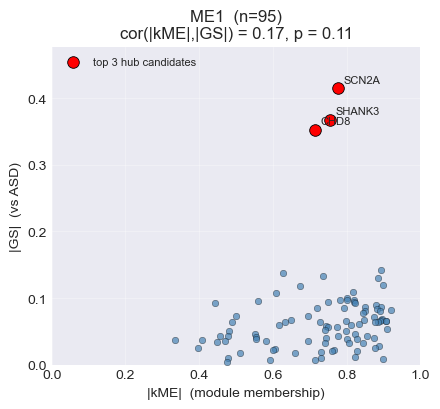

Saved: ../data/ASD_dataset/WGCNA_hub_kME_vs_GS.png


In [69]:
# -----------------------------------------------------------------------------
# Step 10c — Visualise GS vs kME per module
#
# One scatter plot per module:
#   * x-axis = |kME|  (network centrality within the module)
#   * y-axis = |GS|   (correlation with the phenotype)
# Hub candidates live in the UPPER-RIGHT corner. The top-3 are highlighted in
# red and labelled with the gene name.
#
# A high cor(|kME|, |GS|) within a module is exactly what we want — it means
# the genes that drive the module are also the ones aligned with the trait.
# -----------------------------------------------------------------------------
modules_to_plot = [m for m in ME_df.columns
                   if (hub_table['AssignedModule'] == m).sum() >= 3]

if not modules_to_plot:
    print("No module has >= 3 assigned genes; skipping per-module scatter.")
else:
    n = len(modules_to_plot)
    fig, axes = plt.subplots(1, n, figsize=(4.5 * n, 4.2), squeeze=False)
    for ax, module in zip(axes[0], modules_to_plot):
        sub = hub_table[hub_table['AssignedModule'] == module].copy()

        # All genes in this module
        ax.scatter(sub['absKME'], sub['absGS'], s=22, alpha=0.7,
                   color='steelblue', edgecolor='k', linewidth=0.3)

        # Highlight + label top-3 hub candidates
        top3 = sub.nlargest(3, 'HubScore')
        ax.scatter(top3['absKME'], top3['absGS'], s=70, color='red',
                   edgecolor='k', linewidth=0.6, label='top 3 hub candidates')
        for _, row in top3.iterrows():
            ax.annotate(row['Gene'], (row['absKME'], row['absGS']),
                        fontsize=8, xytext=(4, 4), textcoords='offset points')

        # Annotate the kME-vs-GS correlation in the title (a hallmark of a
        # well-formed module: |kME| and |GS| should be POSITIVELY correlated).
        if len(sub) > 1:
            r, p = stats.pearsonr(sub['absKME'], sub['absGS'])
            ax.set_title(f"{module}  (n={len(sub)})\ncor(|kME|,|GS|) = {r:.2f}, p = {p:.2g}")
        else:
            ax.set_title(f"{module}  (n={len(sub)})")
        ax.set_xlabel('|kME|  (module membership)')
        ax.set_ylabel(f'|GS|  (vs {trait_of_interest})')
        ax.set_xlim(0, 1); ax.set_ylim(0, max(0.05, sub['absGS'].max() * 1.15))
        ax.grid(True, alpha=0.3)
        if ax is axes[0][0]:
            ax.legend(loc='upper left', fontsize=8)

    plt.tight_layout()
    plt.savefig('../data/ASD_dataset/WGCNA_hub_kME_vs_GS.png',
                dpi=300, bbox_inches='tight')
    plt.show()
    print("Saved: ../data/ASD_dataset/WGCNA_hub_kME_vs_GS.png")


---
## Step 11: Module enrichment — what biology is behind each module?

Modules from WGCNA are unlabelled gene lists. To convert them into named biological
programs ("synaptic signalling", "immune response", ...), run **Over-Representation
Analysis (ORA)** against curated gene-set libraries (GO, KEGG, Reactome, MSigDB Hallmark).

For each module:
- **Foreground** = genes in the module
- **Background** = the genes that entered WGCNA  (NOT the whole genome — using
  the wrong background is the most common mistake)
- **Test** = Fisher exact / hypergeometric

Adjusting per module with BH-FDR is standard. We use `gseapy.enrichr` here
(skip if the package or internet is unavailable).

In [70]:
# -----------------------------------------------------------------------------
# Step 11a — Per-module Over-Representation Analysis (ORA) via Enrichr
#
# Modules from WGCNA are unlabelled gene lists. ORA assigns biological labels
# by asking: are known gene sets (GO, KEGG, MSigDB Hallmark) statistically
# over-represented in this module compared to the background?
#
# Implementation choices that matter:
#   * BACKGROUND = the genes that entered WGCNA  (NOT all of Ensembl).
#     Using the wrong background is the #1 mistake in pathway analysis —
#     it inflates p-values and produces nonsensical "significant" terms.
#   * Skip the grey/unassigned module (mod == 0)  — by definition it has no
#     coherent biological signal.
#   * Skip very small modules (< MIN_MODULE_SIZE) — the test has no power.
#
# `gseapy.enrichr` calls the Enrichr web service AND requires internet.
# We wrap everything in try/except so the notebook still works offline.
# -----------------------------------------------------------------------------
try:
    import gseapy as gp
    GSEAPY_OK = True
except ImportError:
    GSEAPY_OK = False
    print("gseapy not installed; skip with `pip install gseapy` to enable enrichment.")

# Three popular libraries — one broad (GO BP), one curated (KEGG),
# one condensed (MSigDB Hallmark).
GENE_SETS = [
    'GO_Biological_Process_2023',
    'KEGG_2021_Human',
    'MSigDB_Hallmark_2020',
]
TOP_N = 5            # show top N terms per (module, library)
MIN_MODULE_SIZE = 5  # skip tiny modules — no statistical power

enrichment_rows = []
if GSEAPY_OK:
    background = expr_data.columns.tolist()              # CRUCIAL: WGCNA-input genes
    for mod in sorted(module_assignment['ModuleNum'].unique()):
        if mod == 0:
            continue                                     # skip grey/unassigned
        genes = module_assignment.loc[module_assignment['ModuleNum'] == mod, 'Gene'].tolist()
        if len(genes) < MIN_MODULE_SIZE:
            print(f"Module {mod}: only {len(genes)} genes — skipping enrichment.")
            continue
        try:
            enr = gp.enrichr(
                gene_list=genes,
                gene_sets=GENE_SETS,
                background=background,
                organism='human',
                outdir=None,                              # don't write anything to disk
                no_plot=True,
            )
            res = enr.results
        except Exception as exc:
            # Common causes: no internet, Enrichr server hiccup, weird gene IDs
            print(f"Enrichr failed for module {mod}: {exc}")
            continue
        if res is None or res.empty:
            continue

        # Keep top-N hits per (module, library) sorted by adjusted p
        for lib, sub in res.groupby('Gene_set'):
            top = sub.nsmallest(TOP_N, 'Adjusted P-value')
            for _, r in top.iterrows():
                enrichment_rows.append({
                    'Module':   f'ME{int(mod)}',
                    'Library':  lib,
                    'Term':     r['Term'],
                    'P':        r['P-value'],
                    'FDR':      r['Adjusted P-value'],
                    'Genes':    r['Genes'],
                })

enrichment_df = pd.DataFrame(enrichment_rows)
if not enrichment_df.empty:
    enrichment_df.to_csv('../data/ASD_dataset/WGCNA_module_enrichment.csv', index=False)
    print(f"Enrichment hits: {len(enrichment_df)} (across "
          f"{enrichment_df['Module'].nunique()} module(s))")
else:
    print("No enrichment results (offline, gseapy missing, or all modules too small).")


gseapy not installed; skip with `pip install gseapy` to enable enrichment.
No enrichment results (offline, gseapy missing, or all modules too small).


In [71]:
# -----------------------------------------------------------------------------
# Step 11b — Display the top enriched terms per (module, library)
#
# The output below is what turns "Module ME1: 94 genes" into a sentence like
# "Module ME1 captures synaptic glutamatergic transmission and calcium
# signalling" — the named biological program behind the gene cluster.
#
# Long term names and gene strings are truncated to keep the printout tidy.
# -----------------------------------------------------------------------------
if not enrichment_df.empty:
    for (mod, lib), sub in enrichment_df.groupby(['Module', 'Library']):
        print(f"\n=== {mod}  |  {lib} ===")
        view = sub.nsmallest(5, 'FDR')[['Term', 'FDR', 'P', 'Genes']].copy()
        view['Term']  = view['Term'].str.slice(0, 60)        # cosmetic truncation
        view['Genes'] = view['Genes'].str.slice(0, 70)
        view['FDR']   = view['FDR'].map(lambda v: f'{v:.3g}')
        view['P']     = view['P'].map(lambda v: f'{v:.3g}')
        print(view.to_string(index=False))
else:
    print("(enrichment not computed)")


(enrichment not computed)


---
## Summary

In [72]:
# -----------------------------------------------------------------------------
# Final summary — everything we computed in one place
#
# This cell is intentionally just printing — no new computations. It serves as
# the report-style closing of the notebook so a reader who scrolls to the end
# gets:
#   * Dataset shape
#   * The chosen WGCNA parameters
#   * Module sizes and PC1 variance explained
#   * Significant module–trait associations
#   * Top mQTL hits at FDR < 0.10
#   * A list of every output file written under data/ASD_dataset/
# -----------------------------------------------------------------------------
print("="*80)
print("MULTI-OMICS WGCNA + mQTL ANALYSIS COMPLETE")
print("="*80)

# Dataset shape
print("\nDataset:")
print(f"  Samples used: {expr_data.shape[0]}")
print(f"  Genes (WGCNA input): {expr_data.shape[1]}")
print(f"  SNPs (mQTL):         {genotypes.shape[1]}")

# Headline WGCNA parameters
print("\nWGCNA Parameters:")
print(f"  Soft-thresholding power: {beta_optimal}")
print(f"  Number of modules:       {n_target_modules}")

# Per-module breakdown
retained = sorted(set(module_assignment['ModuleNum'].unique()) - {0})
print(f"\nModules ({len(retained)} retained, plus grey/unassigned):")
for mod in sorted(module_assignment['ModuleNum'].unique()):
    sub = module_assignment[module_assignment['ModuleNum'] == mod]
    color = sub['ModuleColor'].iloc[0]
    if mod == 0:
        print(f"  Module {mod} ({color}): {len(sub)} genes  (unassigned)")
    else:
        var = ME_var.get(f'ME{mod}', float('nan'))
        print(f"  Module {mod} ({color}): {len(sub)} genes, "
              f"PC1 variance = {var:.1%}")

# Module-trait significance
print("\nSignificant Module–Trait Associations (p < 0.05):")
found = False
for trait in trait_corr.columns:
    for module in trait_corr.index:
        r = trait_corr.loc[module, trait]; p = trait_pval.loc[module, trait]
        if pd.notna(p) and p < 0.05:
            print(f"  {module} ~ {trait}:  r={r:+.3f},  p={p:.4f}")
            found = True
if not found:
    print("  (none)")

# Top mQTL hits (FDR-controlled)
print("\nTop mQTL hits (FDR < 0.10):")
hits = mqtl_df[mqtl_df['fdr_bh'] < 0.10]
if len(hits):
    for _, row in hits.iterrows():
        print(f"  {row['Module']} ~ {row['SNP']}:  "
              f"beta={row['beta']:+.3f},  p={row['pvalue']:.2g},  "
              f"FDR={row['fdr_bh']:.2g}")
else:
    print("  (none at FDR<0.10 — try larger cohorts or relaxed thresholds)")

# All persisted artefacts
print("\nOutputs written to ../data/ASD_dataset/:")
print("  - WGCNA_module_trait.png")
print("  - WGCNA_mQTL_results.csv")
print("  - WGCNA_mQTL_results.png")
print("  - WGCNA_mQTL_topHit.png")
print("  - WGCNA_hub_candidates.csv")
print("  - WGCNA_hub_kME_vs_GS.png")
print("  - WGCNA_module_enrichment.csv")


MULTI-OMICS WGCNA + mQTL ANALYSIS COMPLETE

Dataset:
  Samples used: 300
  Genes (WGCNA input): 100
  SNPs (mQTL):         50

WGCNA Parameters:
  Soft-thresholding power: 4
  Number of modules:       6

Modules (1 retained, plus grey/unassigned):
  Module 0 (grey): 5 genes  (unassigned)
  Module 1 (turquoise): 95 genes, PC1 variance = 55.6%

Significant Module–Trait Associations (p < 0.05):
  (none)

Top mQTL hits (FDR < 0.10):
  (none at FDR<0.10 — try larger cohorts or relaxed thresholds)

Outputs written to ../data/ASD_dataset/:
  - WGCNA_module_trait.png
  - WGCNA_mQTL_results.csv
  - WGCNA_mQTL_results.png
  - WGCNA_mQTL_topHit.png
  - WGCNA_hub_candidates.csv
  - WGCNA_hub_kME_vs_GS.png
  - WGCNA_module_enrichment.csv
